# 골든배치 15개 평가기준 시각화

## tl;dr

- 목표변수는 **페니실린 농도**이며, 총수확량은 이 노트북에서 사용하지 않는다.
- 선정된 15개 후보 중 RC 8·12·14·16, OC 35·57, APC 62·65·82·85의 10개는 6개 공정 안정성 기준을 모두 통과한다.
- RC 17·26, OC 48, APC 79·68의 5개는 일부 기준 때문에 조건부 후보로 분류된다.
- APC 68은 pH 변동, DO 최솟값, 산 총투입량의 세 기준을 동시에 위반해 우선 재검토 대상이다.

이 노트북은 그래프를 화면에 출력할 뿐 CSV나 다른 데이터 파일을 저장하지 않는다.

## Context & Methods

### 분석 질문

페니실린 농도를 기준으로 선정된 골든배치 15개 중 어떤 배치가 공정 안정성 기준을 모두 만족하며, 조건부 후보는 어떤 기준을 위반했는가?

### 평가기준

1. 후기 페니실린 농도 기울기 ≥ 0
2. pH 표준편차 ≤ 같은 전략 정상 배치의 75분위
3. DO 최솟값 ≥ 같은 전략 정상 배치의 10분위
4. 최종 기질농도 ≤ 같은 전략 정상 배치의 75분위
5. 산 총투입량 ≤ 같은 전략 정상 배치의 90분위
6. 염기 총투입량 ≤ 같은 전략 정상 배치의 90분위

### Key Assumptions

- 골든배치 15개 ID는 이미 선정된 고정 목록으로 사용한다.
- 기준은 정상 배치 90개의 전략별 경험분포로 만든 임시 통계 게이트이며 현장 규격이 아니다.
- 후기 구간은 각 배치 실제 종료시간의 마지막 20%이므로 종료 후 설명용이다.
- `총수확량(kg)`은 계산·분류·시각화에 사용하지 않는다.

In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

# 현재 주피터 커널에 필요한 라이브러리가 없을 때만 같은 커널에 설치합니다.
required_packages = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
}
missing_packages = [
    pip_name for module_name, pip_name in required_packages.items()
    if importlib.util.find_spec(module_name) is None
]
if missing_packages:
    print('현재 커널에 필요한 라이브러리를 설치합니다:', missing_packages)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing_packages])

import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from IPython.display import display


def find_project_root(start=Path.cwd()):
    for root in (start, *start.parents):
        if (root / 'data/interim/merged_data_ko.csv').exists():
            return root
        nested = root / 'penicillin-process-analysis'
        if (nested / 'data/interim/merged_data_ko.csv').exists():
            return nested
    raise FileNotFoundError(
        'merged_data_ko.csv를 찾을 수 없습니다. '
        'penicillin-process-analysis 폴더를 작업공간으로 연 뒤 다시 실행하세요.'
    )


def trapezoid_integral(values, time):
    """NumPy 버전과 관계없이 사다리꼴 적분값을 계산합니다."""
    values = np.asarray(values, dtype=float)
    time = np.asarray(time, dtype=float)
    return np.sum((values[:-1] + values[1:]) * 0.5 * np.diff(time))


def set_korean_font():
    available = {font.name for font in font_manager.fontManager.ttflist}
    for candidate in ['Malgun Gothic', 'AppleGothic', 'Noto Sans CJK KR', 'Arial Unicode MS']:
        if candidate in available:
            plt.rcParams['font.family'] = candidate
            break
    plt.rcParams['axes.unicode_minus'] = False


set_korean_font()
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#98A2B3',
    'axes.labelcolor': '#25324A',
    'xtick.color': '#475467',
    'ytick.color': '#475467',
    'text.color': '#25324A',
    'axes.titleweight': 'bold',
})

BLUE = '#3568A8'
ORANGE = '#C56A1A'
GRID = '#D9DEE7'
INK = '#25324A'

GOLDEN_IDS = [8, 12, 17, 26, 14, 16, 35, 57, 48, 79, 85, 65, 62, 82, 68]
EXPECTED_VERY_SUITABLE = {8, 12, 14, 16, 35, 57, 62, 65, 82, 85}
EXPECTED_CONDITIONAL = {17, 26, 48, 68, 79}

print('실행 Python:', sys.executable)
print(f'numpy {np.__version__} / pandas {pd.__version__}')


실행 Python: d:\QAQC 본캠프\실전 프로젝트\Code\asdf\.venv.3.12\Scripts\python.exe
numpy 2.5.1 / pandas 3.0.5


## Data

### 1. 데이터 불러오기와 기본 검증

In [2]:
data_path = find_project_root() / 'data/interim/merged_data_ko.csv'
data = pd.read_csv(data_path)

required_columns = {
    '배치번호', '발효시간(h)', 'pH', '용존산소(mg/L)', '기질농도(g/L)',
    '산투입유량(L/h)', '염기투입유량(L/h)', '페니실린농도(g/L)'
}
missing_columns = required_columns.difference(data.columns)
assert not missing_columns, f'필수 컬럼 누락: {sorted(missing_columns)}'
assert data['배치번호'].nunique() == 100, '예상 배치 수 100개와 다릅니다.'
assert set(GOLDEN_IDS).issubset(set(data['배치번호'].unique())), '골든배치 ID가 데이터에 없습니다.'

normal = data.loc[data['배치번호'] <= 90].copy()
print(f'원본: {len(data):,}행, {data["배치번호"].nunique()}개 배치')
print(f'정상 비교군: {len(normal):,}행, {normal["배치번호"].nunique()}개 배치')
print('목표변수: 페니실린농도(g/L)')
print('총수확량 사용 여부: 사용하지 않음')

원본: 113,935행, 100개 배치
정상 비교군: 102,410행, 90개 배치
목표변수: 페니실린농도(g/L)
총수확량 사용 여부: 사용하지 않음


### 2. 배치 단위 지표와 전략별 경험적 기준 계산

In [3]:
metric_rows = []

for batch_number, batch in normal.groupby('배치번호', sort=True):
    batch = batch.sort_values('발효시간(h)')
    time = batch['발효시간(h)'].to_numpy(float)
    penicillin = batch['페니실린농도(g/L)'].to_numpy(float)
    substrate = batch['기질농도(g/L)'].to_numpy(float)
    late_mask = time / time[-1] >= 0.8
    strategy = 'RC' if batch_number <= 30 else ('OC' if batch_number <= 60 else 'APC')

    metric_rows.append({
        '배치번호': int(batch_number),
        '전략': strategy,
        '최종페니실린농도': float(penicillin[-1]),
        '후기농도기울기': float(np.polyfit(time[late_mask], penicillin[late_mask], 1)[0]),
        'pH표준편차': float(batch['pH'].std(ddof=1)),
        'DO최솟값': float(batch['용존산소(mg/L)'].min()),
        '최종기질': float(substrate[-1]),
        '산총투입량': float(trapezoid_integral(batch['산투입유량(L/h)'], time)),
        '염기총투입량': float(trapezoid_integral(batch['염기투입유량(L/h)'], time)),
    })

batch_metrics = pd.DataFrame(metric_rows)

limit_rows = []
for strategy, group in batch_metrics.groupby('전략'):
    limit_rows.append({
        '전략': strategy,
        'pH기준': group['pH표준편차'].quantile(0.75),
        'DO기준': group['DO최솟값'].quantile(0.10),
        '기질기준': group['최종기질'].quantile(0.75),
        '산기준': group['산총투입량'].quantile(0.90),
        '염기기준': group['염기총투입량'].quantile(0.90),
    })

empirical_limits = pd.DataFrame(limit_rows)
display(empirical_limits.round(4))

,전략,pH기준,DO기준,기질기준,산기준,염기기준
0,APC,0.0261,4.1534,0.0016,4.4752,22046.1556
1,OC,0.0305,5.8239,40.2890,44.1889,18915.0209
2,RC,0.0290,6.0710,42.6935,42.5901,16873.2715


### 3. 여섯 가지 게이트 적용과 분류 검증

In [4]:
evaluation = batch_metrics.merge(empirical_limits, on='전략', how='left')

evaluation['후기 농도'] = evaluation['후기농도기울기'] >= 0
evaluation['pH'] = evaluation['pH표준편차'] <= evaluation['pH기준']
evaluation['DO'] = evaluation['DO최솟값'] >= evaluation['DO기준']
evaluation['기질'] = evaluation['최종기질'] <= evaluation['기질기준']
evaluation['산'] = evaluation['산총투입량'] <= evaluation['산기준']
evaluation['염기'] = evaluation['염기총투입량'] <= evaluation['염기기준']

check_columns = ['후기 농도', 'pH', 'DO', '기질', '산', '염기']
evaluation['통과수'] = evaluation[check_columns].sum(axis=1)
evaluation['전체통과'] = evaluation[check_columns].all(axis=1)

selected = evaluation.loc[evaluation['배치번호'].isin(GOLDEN_IDS)].copy()
selected['평가등급'] = np.where(selected['전체통과'], '매우 적합', '조건부 합당')

computed_very = set(selected.loc[selected['전체통과'], '배치번호'])
computed_conditional = set(selected.loc[~selected['전체통과'], '배치번호'])
assert computed_very == EXPECTED_VERY_SUITABLE, (computed_very, EXPECTED_VERY_SUITABLE)
assert computed_conditional == EXPECTED_CONDITIONAL, (computed_conditional, EXPECTED_CONDITIONAL)
assert len(selected) == 15 and selected['전체통과'].sum() == 10

grade_order = {'매우 적합': 0, '조건부 합당': 1}
strategy_order = {'RC': 0, 'OC': 1, 'APC': 2}
selected['_grade_order'] = selected['평가등급'].map(grade_order)
selected['_strategy_order'] = selected['전략'].map(strategy_order)
selected = selected.sort_values(['_grade_order', '_strategy_order', '배치번호']).drop(
    columns=['_grade_order', '_strategy_order']
)

summary = selected.groupby('평가등급', sort=False).agg(
    배치수=('배치번호', 'size'),
    평균최종페니실린농도=('최종페니실린농도', 'mean'),
    평균통과수=('통과수', 'mean'),
)
display(summary.round(3))
display(selected[['배치번호', '전략', '평가등급', '최종페니실린농도', *check_columns, '통과수']])

,배치수,평균최종페니실린농도,평균통과수
평가등급,,,
매우 적합,10,31.242,6.0
조건부 합당,5,30.630,4.6


,배치번호,전략,평가등급,최종페니실린농도,후기 농도,pH,DO,기질,산,염기,통과수
7,8,RC,매우 적합,34.508,True,True,True,True,True,True,6
11,12,RC,매우 적합,30.102,True,True,True,True,True,True,6
13,14,RC,매우 적합,28.548,True,True,True,True,True,True,6
15,16,RC,매우 적합,32.124,True,True,True,True,True,True,6
34,35,OC,매우 적합,28.302,True,True,True,True,True,True,6
56,57,OC,매우 적합,32.518,True,True,True,True,True,True,6
61,62,APC,매우 적합,32.198,True,True,True,True,True,True,6
64,65,APC,매우 적합,32.211,True,True,True,True,True,True,6
81,82,APC,매우 적합,30.011,True,True,True,True,True,True,6
84,85,APC,매우 적합,31.898,True,True,True,True,True,True,6


## Results

### 1. 목표변수: 선정 배치별 최종 페니실린 농도

막대는 각 배치의 최종 페니실린 농도이며, 점선은 같은 전략의 정상 30개 배치 평균이다. 파란색은 6개 게이트 전체 통과, 주황색은 조건부 후보를 뜻한다.

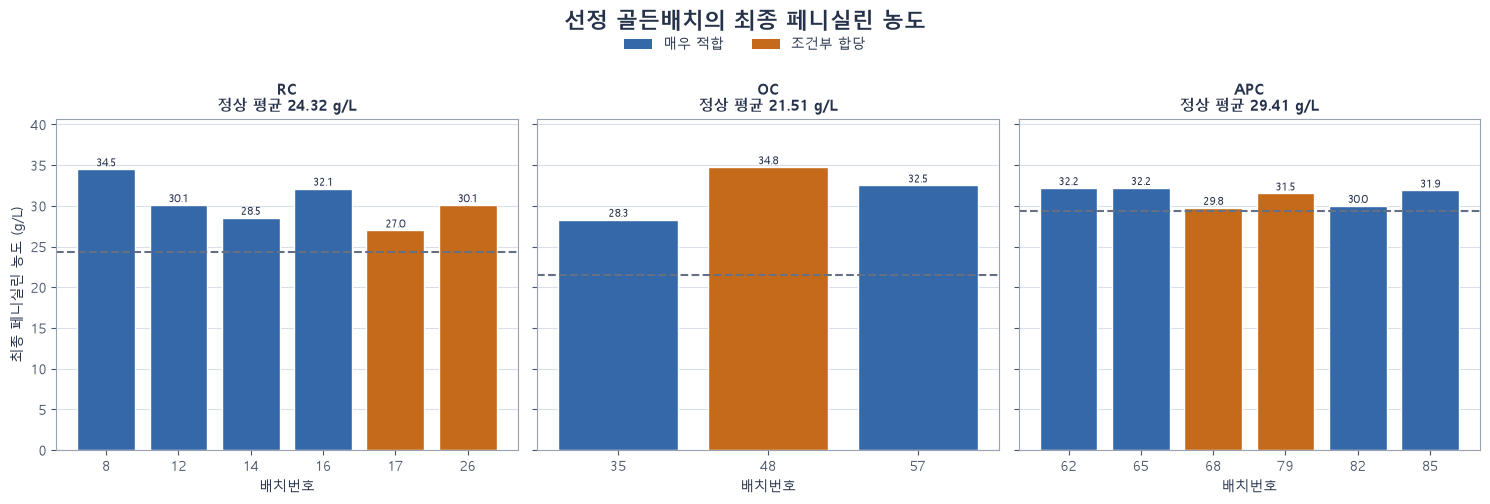

In [5]:
strategy_means = batch_metrics.groupby('전략')['최종페니실린농도'].mean()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)
for ax, strategy in zip(axes, ['RC', 'OC', 'APC']):
    group = selected.loc[selected['전략'] == strategy].sort_values('배치번호')
    colors = group['평가등급'].map({'매우 적합': BLUE, '조건부 합당': ORANGE})
    bars = ax.bar(group['배치번호'].astype(str), group['최종페니실린농도'], color=colors, edgecolor='white')
    ax.axhline(strategy_means[strategy], color='#667085', linestyle='--', linewidth=1.5)
    ax.set_title(f'{strategy}\n정상 평균 {strategy_means[strategy]:.2f} g/L', fontsize=11)
    ax.set_xlabel('배치번호')
    ax.grid(axis='y', color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for bar, value in zip(bars, group['최종페니실린농도']):
        ax.text(bar.get_x() + bar.get_width()/2, value + 0.35, f'{value:.1f}', ha='center', fontsize=8)

axes[0].set_ylabel('최종 페니실린 농도 (g/L)')
axes[0].set_ylim(0, max(36, selected['최종페니실린농도'].max() * 1.17))
fig.suptitle('선정 골든배치의 최종 페니실린 농도', fontsize=16, fontweight='bold', y=1.04)
fig.legend(
    handles=[Patch(facecolor=BLUE, label='매우 적합'), Patch(facecolor=ORANGE, label='조건부 합당')],
    loc='upper center', bbox_to_anchor=(0.5, 1.01), ncol=2, frameon=False
)
plt.tight_layout()
plt.show()

### 2. 15개 배치 × 6개 평가기준 통과 행렬

색상뿐 아니라 ●(통과)와 △(재검토)를 함께 표시한다.

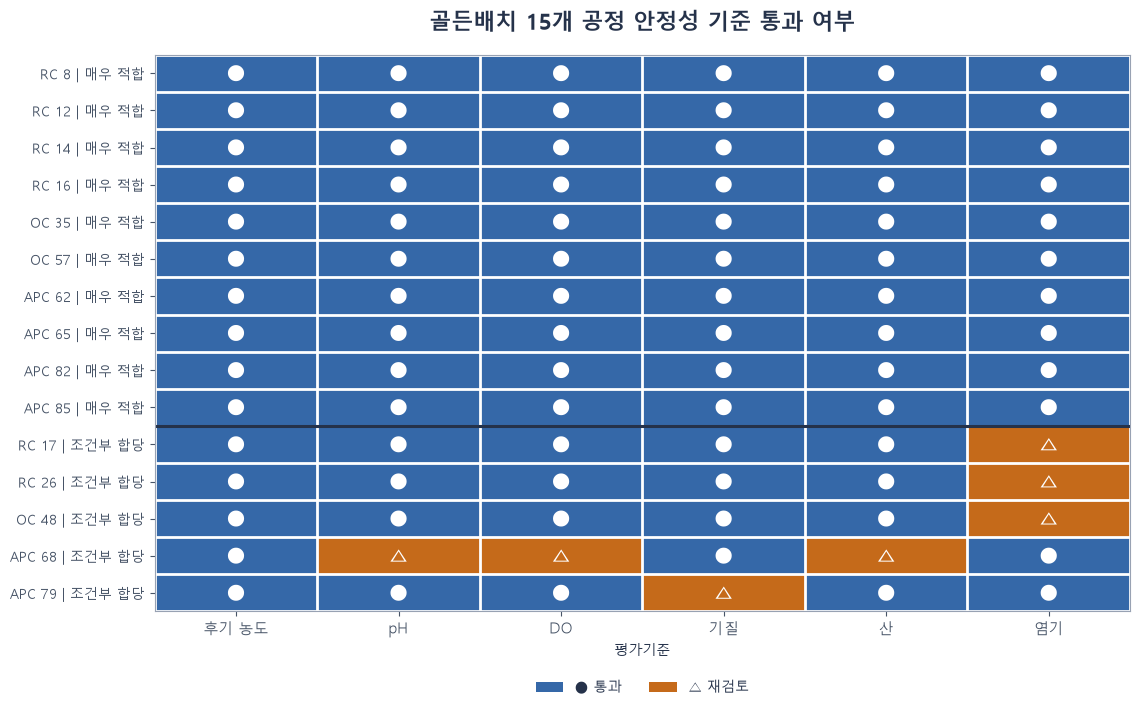

In [6]:
matrix = selected[check_columns].astype(int).to_numpy()
row_labels = [
    f'{strategy} {batch} | {grade}'
    for strategy, batch, grade in selected[['전략', '배치번호', '평가등급']].itertuples(index=False, name=None)
]

fig, ax = plt.subplots(figsize=(11.5, 7.2))
ax.imshow(matrix, aspect='auto', cmap=ListedColormap([ORANGE, BLUE]), vmin=0, vmax=1)

ax.set_xticks(range(len(check_columns)))
ax.set_xticklabels(check_columns, fontsize=11)
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=10)
ax.set_xticks(np.arange(-0.5, len(check_columns), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(row_labels), 1), minor=True)
ax.grid(which='minor', color='white', linewidth=2)
ax.tick_params(which='minor', bottom=False, left=False)
ax.axhline(9.5, color=INK, linewidth=2.2)

for row in range(matrix.shape[0]):
    for col in range(matrix.shape[1]):
        symbol = '●' if matrix[row, col] else '△'
        ax.text(col, row, symbol, ha='center', va='center', color='white', fontsize=14, fontweight='bold')

ax.set_title('골든배치 15개 공정 안정성 기준 통과 여부', fontsize=16, pad=18)
ax.set_xlabel('평가기준')
ax.legend(
    handles=[Patch(facecolor=BLUE, label='● 통과'), Patch(facecolor=ORANGE, label='△ 재검토')],
    loc='upper center', bbox_to_anchor=(0.5, -0.10), ncol=2, frameon=False
)
plt.tight_layout()
plt.show()

### 3. 평가등급별 기준 통과율

매우 적합 10개와 조건부 5개가 각 기준을 얼마나 자주 통과했는지 비교한다. 모든 막대는 0%부터 시작한다.

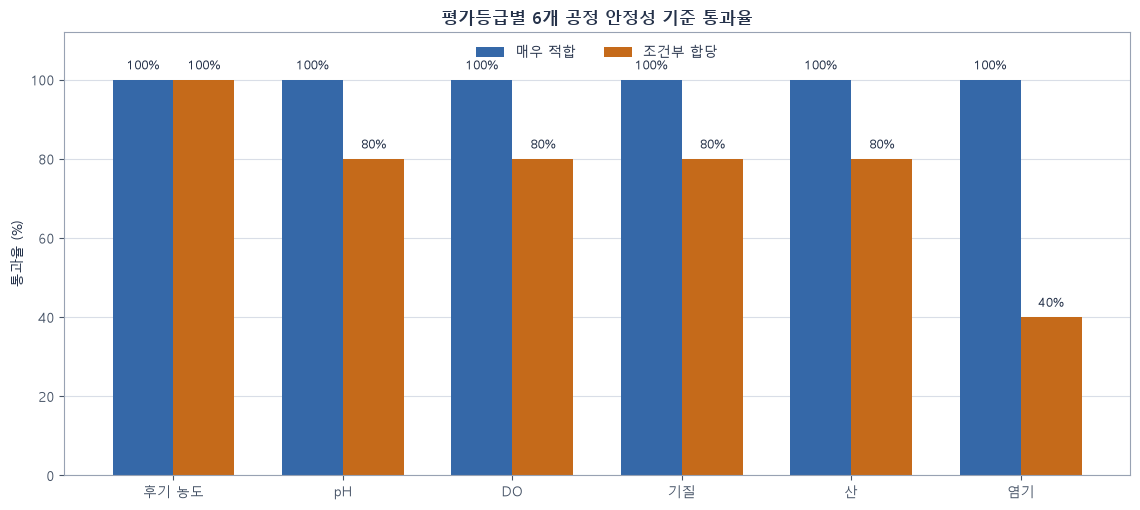

In [7]:
pass_rates = (
    selected.groupby('평가등급')[check_columns]
    .mean()
    .mul(100)
    .reindex(['매우 적합', '조건부 합당'])
)

x = np.arange(len(check_columns))
width = 0.36
fig, ax = plt.subplots(figsize=(11.5, 5.2))

for offset, grade, color in [(-width/2, '매우 적합', BLUE), (width/2, '조건부 합당', ORANGE)]:
    bars = ax.bar(x + offset, pass_rates.loc[grade], width, label=grade, color=color)
    for bar, value in zip(bars, pass_rates.loc[grade]):
        ax.text(bar.get_x() + bar.get_width()/2, value + 2, f'{value:.0f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(check_columns)
ax.set_ylim(0, 112)
ax.set_ylabel('통과율 (%)')
ax.set_title('평가등급별 6개 공정 안정성 기준 통과율')
ax.grid(axis='y', color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False, ncol=2, loc='upper center')
plt.tight_layout()
plt.show()

### 4. 조건부 후보의 기준 위반 정도

위반한 기준만 표시한다. 값은 경험적 기준을 얼마나 초과했거나 미달했는지를 백분율로 나타낸다. 이 비율은 통계 기준과의 거리이며 현장 위험도의 크기를 뜻하지 않는다.

,배치,평가기준,실제값,기준값,위반정도(%),방향
2,OC 48,염기,19360.857808,18915.020949,2.4,기준 초과율
1,RC 26,염기,18080.916340,16873.271495,7.2,기준 초과율
3,APC 68,pH,0.028375,0.026129,8.6,기준 초과율
0,RC 17,염기,18639.642180,16873.271495,10.5,기준 초과율
6,APC 79,기질,0.002141,0.001643,30.3,기준 초과율
4,APC 68,DO,2.693200,4.153380,35.2,기준 미달률
5,APC 68,산,7.266326,4.475219,62.4,기준 초과율


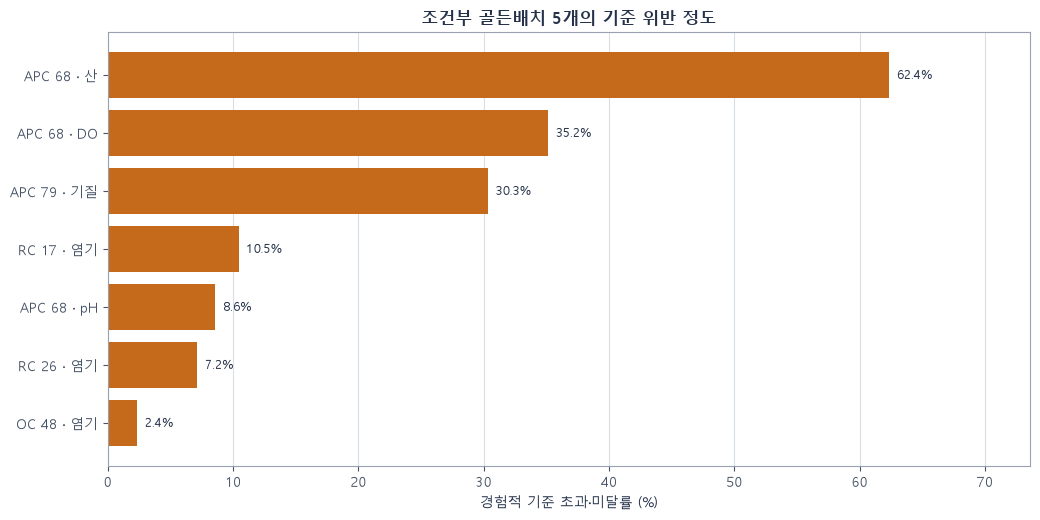

In [8]:
metric_specs = {
    '후기 농도': ('후기농도기울기', 0.0, 'lower'),
    'pH': ('pH표준편차', 'pH기준', 'upper'),
    'DO': ('DO최솟값', 'DO기준', 'lower'),
    '기질': ('최종기질', '기질기준', 'upper'),
    '산': ('산총투입량', '산기준', 'upper'),
    '염기': ('염기총투입량', '염기기준', 'upper'),
}

failure_rows = []
for _, row in selected.loc[selected['평가등급'] == '조건부 합당'].iterrows():
    for criterion, (value_col, limit_col, direction) in metric_specs.items():
        if bool(row[criterion]):
            continue
        actual = float(row[value_col])
        limit = float(limit_col if isinstance(limit_col, float) else row[limit_col])
        if direction == 'upper':
            distance_pct = (actual - limit) / abs(limit) * 100
            distance_label = '기준 초과율'
        else:
            distance_pct = (limit - actual) / abs(limit) * 100 if limit != 0 else np.nan
            distance_label = '기준 미달률'
        failure_rows.append({
            '배치': f'{row["전략"]} {int(row["배치번호"])}',
            '평가기준': criterion,
            '실제값': actual,
            '기준값': limit,
            '위반정도(%)': distance_pct,
            '방향': distance_label,
        })

failures = pd.DataFrame(failure_rows).sort_values('위반정도(%)')
display(failures.round({'실제값': 6, '기준값': 6, '위반정도(%)': 1}))

labels = failures['배치'] + ' · ' + failures['평가기준']
fig, ax = plt.subplots(figsize=(10.5, 5.3))
bars = ax.barh(labels, failures['위반정도(%)'], color=ORANGE)
for bar, value in zip(bars, failures['위반정도(%)']):
    ax.text(value + 0.6, bar.get_y() + bar.get_height()/2, f'{value:.1f}%', ha='left', va='center', fontsize=9)
ax.set_xlim(0, failures['위반정도(%)'].max() * 1.18)
ax.set_xlabel('경험적 기준 초과·미달률 (%)')
ax.set_title('조건부 골든배치 5개의 기준 위반 정도')
ax.grid(axis='x', color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## Takeaways

### 최종 판단

- **매우 적합 10개:** RC 8·12·14·16, OC 35·57, APC 62·65·82·85는 후기 페니실린 농도 유지와 5개 안정성 기준을 모두 통과했다.
- **조건부 합당 4개:** RC 17·26과 OC 48은 염기 총투입량만, APC 79는 최종 기질 기준만 위반했다. 다른 5개 기준을 통과했으므로 현장 허용범위를 확인한 뒤 조건부 유지할 수 있다.
- **우선 재검토 1개:** APC 68은 pH 변동, DO 최솟값, 산 총투입량의 세 기준을 동시에 위반했다.
- 이 분류는 **페니실린 농도를 목표변수로 선정한 15개 후보**를 공정 안정성 관점에서 다시 나눈 것이다. 총수확량은 사용하지 않았다.

### 해석상 주의

‘매우 적합’은 현재 데이터의 전략별 경험적 기준을 모두 통과했다는 뜻이다. 현장 공정 규격이나 독립 배치 검증을 통과했다는 의미는 아니므로 최종 골든배치 확정 전 현장 허용범위와 별도 배치 재검증이 필요하다.